# **Multioutput Forecaster & Phase Detector**

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, classification_report, confusion_matrix

pd.set_option("display.max_columns", 200)

features = [
    'moisture_active1', 'moisture_active2', 'oxygen', 'co2',
    'temperature_curing1', 'temperature_curing2',
    'moisture_curing1', 'moisture_curing2',
    'methane', 'temperature_active1', 'temperature_active2',
    'temperature_active3', 'temperature_active4'
]

# ---- Temperatures we want to forecast (multi-output) ----
TARGET_TEMPS = [
    'temperature_active1', 'temperature_active2',
    'temperature_active3', 'temperature_active4',
    'temperature_curing1', 'temperature_curing2',
]

LAGS = [1, 2, 3]

# slope to phase thresholds
SLOPE_HEAT = 0.2
SLOPE_COOL = -0.2

CSV_PATH = "oversampled.csv"

### **Load sort and basic cleaning**

In [8]:
df = pd.read_csv(CSV_PATH)

df['time_stamp'] = pd.to_datetime(df['time_stamp'])
df = df.sort_values(['run_id', 'time_stamp']).reset_index(drop=True)

# making sure the columns we need exists
need = set(['run_id', 'time_stamp']) | set(features)
missing = need - set(df.columns)
assert not missing, f"Missing columns: {missing}"

# cast all feature cols numeric
for c in features:
    df[c] = pd.to_numeric(df[c], errors='coerce')

print(df[['run_id', 'time_stamp'] + features].head(3))

   run_id time_stamp  moisture_active1  moisture_active2     oxygen  \
0       0 2024-06-29         14.967363          9.911543  14.466904   
1       0 2024-06-30         16.787177         14.923514  12.999908   
2       0 2024-07-01         18.371942         19.981339  11.591300   

           co2  temperature_curing1  temperature_curing2  moisture_curing1  \
0  6641.257138                  0.0                  0.0        103.292406   
1  6624.210615                  0.0                  0.0         66.846325   
2  6611.307877                  0.0                  0.0         27.837396   

   moisture_curing2      methane  temperature_active1  temperature_active2  \
0         21.911985  1188.940923            16.110218            16.038542   
1         23.895143   990.811700            17.040312            17.500513   
2         25.975003   787.953760            17.863429            18.981076   

   temperature_active3  temperature_active4  
0            15.971990            15.924054

### **Derive phase labels from a rolling slope on a core temperature**

In [9]:
CORE_TEMP = 'temperature_active1' # used for phase derivation

def rolling_slope(series, window=5):
    s = pd.to_numeric(series, errors='coerce')
    x = np.arange(window).reshape(-1,1)
    lr = LinearRegression()
    slopes = np.full(len(s), np.nan)
    for i in range(window-1, len(s)):
        y = s.iloc[i-window+1:i+1].values
        lr.fit(x, y)
        slopes[i] = lr.coef_[0]

    return pd.Series(slopes, index=series.index)

# compute slope per run
df['temp_slope_5'] = np.nan
for rid, g in df.groupby('run_id', sort=False):
    s = rolling_slope(g[CORE_TEMP], window=5)
    df.loc[g.index, 'temp_slope_5'] = s.values

def slop_to_phase(val):
    if np.isnan(val): return 'unknown'
    if val >= SLOPE_HEAT: return 'heating' 
    if val <= SLOPE_COOL: return 'cooling' 
    return 'stable' 

df['phase'] = df['temp_slope_5'].apply(slop_to_phase)

# Next-step labels
df['phase_next'] = df.groupby('run_id')['phase'].shift(-1)
df['phase_change_next'] = (df['phase_next'] != df['phase']).astype(int)

# Next-step targets for ALL temperature columns
for tcol in TARGET_TEMPS:
    df[f'{tcol}_next'] = df.groupby('run_id')[tcol].shift(-1)

# Remove rows without next-step info
next_targets = [f'{t}_next' for t in TARGET_TEMPS]
df = df.dropna(subset=next_targets + ['phase_next']).reset_index(drop=True)

df[['run_id', 'time_stamp', 'phase', 'phase_next', 'phase_change_next'] + next_targets].head(8)

,run_id,time_stamp,phase,phase_next,phase_change_next,temperature_active1_next,temperature_active2_next,temperature_active3_next,temperature_active4_next,temperature_curing1_next,temperature_curing2_next
0,0,2024-06-29,unknown,unknown,0,17.040312,17.500513,18.470686,17.013907,0.0,0.0
1,0,2024-06-30,unknown,unknown,0,17.863429,18.981076,21.056361,17.944057,0.0,0.0
2,0,2024-07-01,unknown,unknown,0,20.011395,21.992288,26.024076,19.122516,0.0,0.0
3,0,2024-07-02,unknown,heating,1,23.947039,24.955405,29.997829,22.847942,0.0,0.0
4,0,2024-07-03,heating,heating,0,25.949648,24.998243,29.076481,26.076257,0.0,0.0
5,0,2024-07-04,heating,heating,0,24.207421,22.942218,26.998087,24.526839,0.0,0.0
6,0,2024-07-05,heating,heating,0,21.980326,20.970494,25.044159,22.914044,0.0,0.0
7,0,2024-07-06,heating,cooling,1,20.852769,20.673114,23.915171,21.776386,0.0,0.0


### **Build Lag features**
- lags are previous time steps of the same variables, used as features so the model can learn from the recent history.

In [10]:
base_cols = features + TARGET_TEMPS
base_cols_unique = list(dict.fromkeys(base_cols)) # remove dupes

def add_lags(frame, cols, lags=LAGS):
    out = frame.copy()
    for c in cols:
        for L in LAGS:
            out[f'{c}_lag{L}'] = out.groupby('run_id', sort=False)[c].shift(L)
    
    return out

df_lagged = add_lags(df, base_cols_unique, lags=LAGS)

# columns we'll use for modeling
lag_cols = [f'{c}_lag{L}' for c in base_cols_unique for L in LAGS]

df_lagged = df_lagged.dropna(subset=lag_cols + next_targets + ['phase_next']).reset_index(drop=True)

print("Lagged rows:", len(df_lagged), "Lag features:", len(lag_cols))

Lagged rows: 245 Lag features: 39


### **Time-Aware split (by run_id)**

In [11]:
unique_runs = sorted(df_lagged['run_id'].unique().tolist())
if len(unique_runs) < 2:
    raise ValueError("Need >= 2 run_id values for a proper time-aware split.")

train_runs = unique_runs[:-1]
test_runs = unique_runs[-1:]

train = df_lagged[df_lagged['run_id'].isin(train_runs)].copy()
test = df_lagged[df_lagged['run_id'].isin(test_runs)].copy()

print("Train runs:", train_runs, "Test_runs:", test_runs)
print("Train Rows:", len(train), "Test rows:", len(test))

Train runs: [0, 1, 2, 3] Test_runs: [4]
Train Rows: 196 Test rows: 49


### **Multi-output temperature forecaster**

Per target next-step MAE (holdout run):
    temperature_active1_next: 0.055
    temperature_active2_next: 0.032
    temperature_active3_next: 0.071
    temperature_active4_next: 0.056
    temperature_curing1_next: 0.000
    temperature_curing2_next: 0.000


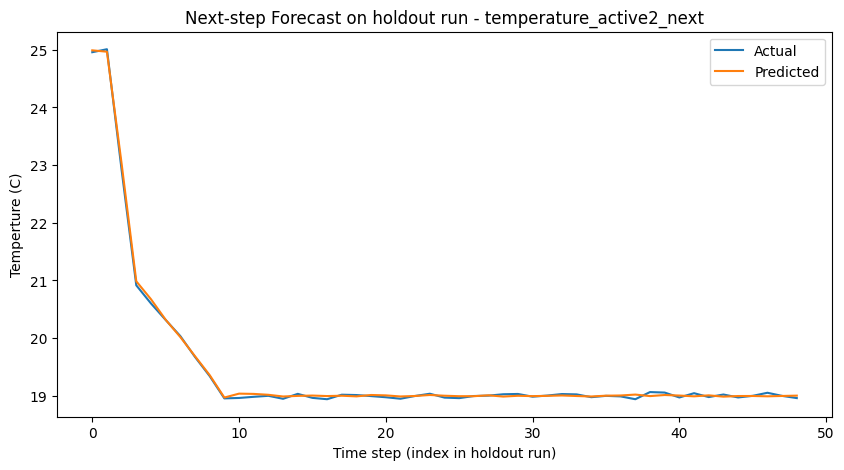

In [12]:
X_cols_reg = lag_cols
X_train_reg = train[X_cols_reg]
X_test_reg = test[X_cols_reg]

y_train_reg = train[next_targets].copy() # shape: (n_samples, n_targets)
y_test_reg = test[next_targets].copy()

# multi-output = one RF per target, trained jointly
base_rf = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
reg_multi = MultiOutputRegressor(base_rf)

reg_multi.fit(X_train_reg, y_train_reg)

FEATURE_ORDER_REG = list(X_train_reg.columns)

y_pred_reg = pd.DataFrame(reg_multi.predict(X_test_reg),
                          columns=next_targets,
                          index=y_test_reg.index)

mae_per_target = {t: mean_absolute_error(y_test_reg[t], y_pred_reg[t]) for t in next_targets}
print("Per target next-step MAE (holdout run):")
for t, v in mae_per_target.items():
    print(f"    {t}: {v:.3f}")

plot_t = 'temperature_active2_next'
plt.figure(figsize=(10,5)) 
plt.plot(y_test_reg[plot_t].values, label='Actual')
plt.plot(y_pred_reg[plot_t].values, label='Predicted')
plt.xlabel("Time step (index in holdout run)")
plt.ylabel("Temperture (C)")
plt.title(f"Next-step Forecast on holdout run - {plot_t}")
plt.legend()
plt.show()

### **Phase detector**

In [13]:
# Phase Detector

X_cols_cls = lag_cols
X_train_cls = train[X_cols_cls]
X_test_cls = test[X_cols_cls]

# 1. Multiclass detector
y_train_phase = train['phase_next']
y_test_phase = test['phase_next']

cls_phase = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

cls_phase.fit(X_train_cls, y_train_phase)
y_pred_phase = cls_phase.predict(X_test_cls)

print("[CLS] phase_next (multiclass) on holdout run")
print(classification_report(y_test_phase, y_pred_phase))
print(confusion_matrix(y_test_phase, y_pred_phase))

FEATURE_ORDER_CLS = list(X_train_cls.columns)

[CLS] phase_next (multiclass) on holdout run
              precision    recall  f1-score   support

     cooling       1.00      1.00      1.00         9
     heating       1.00      1.00      1.00         4
      stable       1.00      1.00      1.00        36

    accuracy                           1.00        49
   macro avg       1.00      1.00      1.00        49
weighted avg       1.00      1.00      1.00        49

[[ 9  0  0]
 [ 0  4  0]
 [ 0  0 36]]


In [14]:
# # 2. Binary phase-change 
# y_train_change = train['phase_change_next']
# y_test_change = test['phase_change_next']

# cls_change = RandomForestClassifier(
#     n_estimators=500,
#     class_weight="balanced_subsample", 
#     random_state=42,
#     n_jobs=-1
# )

# cls_change.fit(X_train_cls, y_train_change)
# y_pred_change = cls_change.predict(X_test_cls)

# print("[CLS] phase-change-next (binary) on holdout run")
# print(classification_report(y_test_change, y_pred_change))
# print(confusion_matrix(y_test_change, y_pred_change))

### **Multi step roll forward simulator (multi-output temps)**
- starts from the last max(LAGS) observed rows of the test run
- keeps non temperature sensors constant
- predicts all *_next temperatures each step and writes them back

In [15]:
from datetime import timedelta

# Non-temperature sensors (kept constant here; you can also train forecasters for them)
temp_cols = TARGET_TEMPS[:]  # raw temp sensors we roll forward
non_temp_feats = [c for c in features if c not in temp_cols]

# Base raw columns used inside the simulator (deduped)
base_cols_multi = list(dict.fromkeys(features + temp_cols))

def roll_forward_forecast_multi(
    last_rows: pd.DataFrame,
    start_date: pd.Timestamp,
    days_ahead: int = 14,
    const_feature_values: dict = None,
    with_phase: bool = True,
):
    """
    last_rows: recent observed rows (>= max(LAGS)) with columns base_cols_multi
    start_date: first future date
    days_ahead: forecast horizon
    const_feature_values: optional dict to hold non-temp sensors constant
    with_phase: whether to also classify the next-day phase along the trajectory
    """
    LAG_WINDOW = max(LAGS)
    assert len(last_rows) >= LAG_WINDOW, f"Need >= {LAG_WINDOW} seed rows"

    # Work buffer = raw sensors only, no lag columns
    work = last_rows[base_cols_multi].copy().reset_index(drop=True)

    # Constants for non-temp sensors
    if const_feature_values is None:
        const_vals = work.tail(LAG_WINDOW)[non_temp_feats].mean().to_dict()
    else:
        const_vals = const_feature_values.copy()

    preds = []
    current_date = start_date

    for step in range(days_ahead):
        # Build lag features from current buffer
        temp_df = work.copy()
        for c in base_cols_multi:
            for L in LAGS:
                temp_df[f'{c}_lag{L}'] = temp_df[c].shift(L)

        row = temp_df.iloc[[-1]]
        # Align to exact training feature order
        x_reg = row.reindex(columns=FEATURE_ORDER_REG, fill_value=np.nan)
        if x_reg.isna().any().any():
            x_reg = x_reg.fillna(method='ffill', axis=1).fillna(method='bfill', axis=1).fillna(0.0)

        next_vec = reg_multi.predict(x_reg)[0]   # array aligned to next_targets
        next_dict = {t: float(v) for t, v in zip(next_targets, next_vec)}

        out_row = {"date": current_date.date(), **next_dict}

        if with_phase:
            # reuse same lag features; if you prefer binary detector, swap cls_phase->cls_change
            x_cls = row.reindex(columns=FEATURE_ORDER_CLS, fill_value=np.nan)
            if x_cls.isna().any().any():
                x_cls = x_cls.fillna(method='ffill', axis=1).fillna(method='bfill', axis=1).fillna(0.0)
            out_row["pred_phase_next"] = cls_phase.predict(x_cls)[0]

        preds.append(out_row)

        # Advance: make a new raw row = predicted temps + constant non-temp sensors
        new_raw = {}
        # 1) non-temp sensors held constant
        for c in non_temp_feats:
            new_raw[c] = const_vals.get(c, work.iloc[-1][c])
        # 2) temperatures: strip "_next" suffix when writing back to raw columns
        for t_next in next_targets:
            raw_col = t_next.replace('_next','')
            new_raw[raw_col] = next_dict[t_next]
        # ensure all temps exist
        for t in temp_cols:
            new_raw.setdefault(t, work.iloc[-1][t])

        work = pd.concat([work, pd.DataFrame([new_raw])], ignore_index=True)
        current_date += timedelta(days=1)

    out = pd.DataFrame(preds)
    if with_phase:
        out['phase_change_flag'] = out['pred_phase_next'].ne(out['pred_phase_next'].shift(1))
    return out


### **Run multi step forecast + plot**

C:\Users\ashle\AppData\Local\Temp\ipykernel_51800\4259328720.py:50: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x_reg = x_reg.fillna(method='ffill', axis=1).fillna(method='bfill', axis=1).fillna(0.0)
C:\Users\ashle\AppData\Local\Temp\ipykernel_51800\4259328720.py:50: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x_reg = x_reg.fillna(method='ffill', axis=1).fillna(method='bfill', axis=1).fillna(0.0)
C:\Users\ashle\AppData\Local\Temp\ipykernel_51800\4259328720.py:61: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x_cls = x_cls.fillna(method='ffill', axis=1).fillna(method='bfill', axis=1).fillna(0.0)
C:\Users\ashle\AppData\Local\Temp\ipykernel_51800\4259328720.py:61: FutureWarning: DataFrame.fillna with 'method' is d

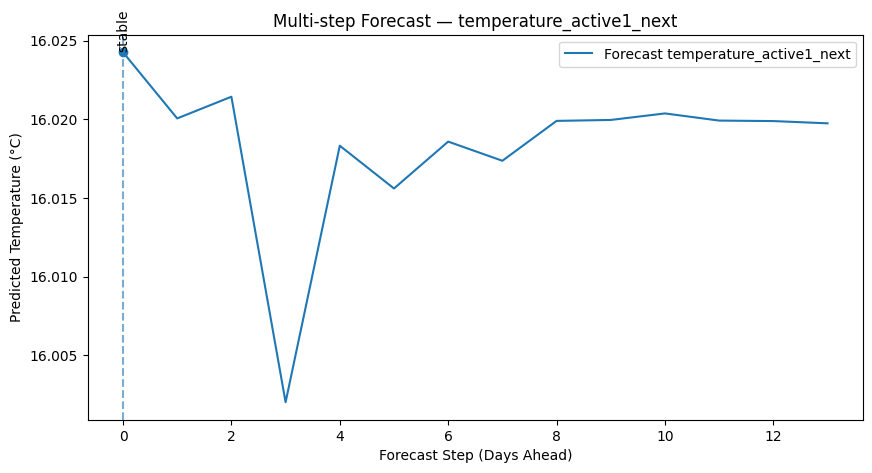

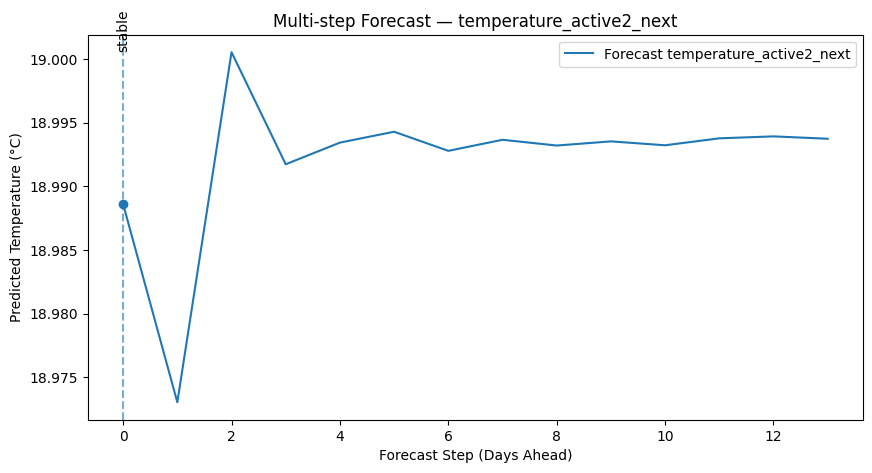

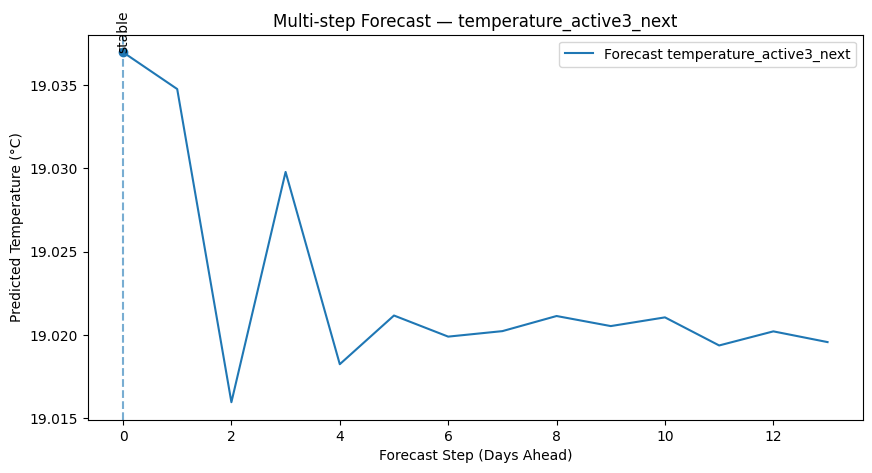

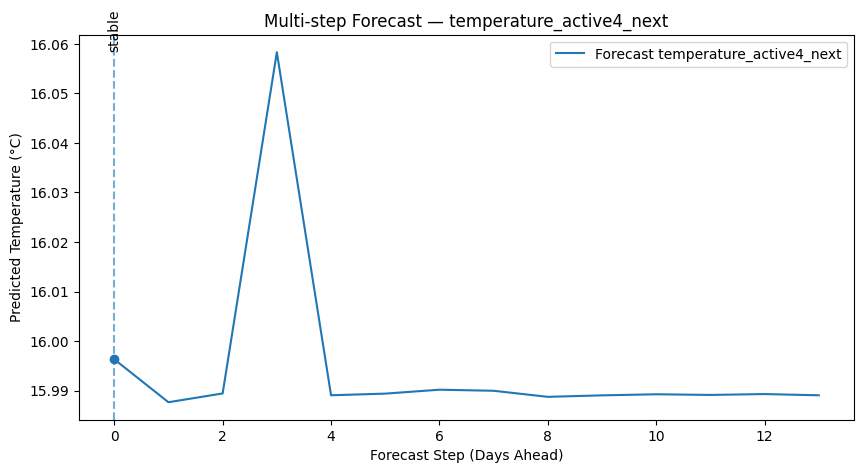

,date,pred_phase_next,phase_change_flag
0,2025-03-24,stable,True
1,2025-03-25,stable,False
2,2025-03-26,stable,False
3,2025-03-27,stable,False
4,2025-03-28,stable,False
5,2025-03-29,stable,False
6,2025-03-30,stable,False
7,2025-03-31,stable,False
8,2025-04-01,stable,False
9,2025-04-02,stable,False


In [16]:
LAG_WINDOW   = max(LAGS)
test_run_id  = test_runs[0]
observed_test = df[df['run_id'] == test_run_id].sort_values('time_stamp')

# Seed the simulator with the last LAG_WINDOW rows of the holdout run
seed_cols = base_cols_multi
seed_rows = observed_test.tail(LAG_WINDOW)[seed_cols].copy()

start_date = observed_test['time_stamp'].iloc[-1] + pd.Timedelta(days=1)

future_multi = roll_forward_forecast_multi(
    last_rows=seed_rows,
    start_date=start_date,
    days_ahead=14,
    const_feature_values=None,
    with_phase=True
)

# Plot a couple of target forecasts with labels
for t_next in ['temperature_active1_next', 'temperature_active2_next', 'temperature_active3_next', 'temperature_active4_next']:
    plt.figure(figsize=(10,5))
    plt.plot(future_multi.index, future_multi[t_next], label=f'Forecast {t_next}')

    change_ix = future_multi.index[ future_multi.get('phase_change_flag', False) ]
    for i in change_ix:
        plt.axvline(i, linestyle='--', alpha=0.6)
        plt.scatter(i, future_multi.loc[i, t_next], zorder=3)

    if 'pred_phase_next' in future_multi.columns:
        for i in change_ix:
            plt.text(i, future_multi[t_next].max(), str(future_multi.loc[i, 'pred_phase_next']),
                     rotation=90, va='bottom', ha='center')

    plt.xlabel("Forecast Step (Days Ahead)")      # X label
    plt.ylabel("Predicted Temperature (°C)")      # Y label
    plt.title(f"Multi-step Forecast — {t_next}")
    plt.legend()
    plt.show()

# Inspect predicted phases / change flags
cols_to_show = ['date', 'pred_phase_next', 'phase_change_flag'] if 'pred_phase_next' in future_multi.columns else ['date']
display(future_multi[cols_to_show].head(10))


# **Expected date output**

In [17]:
from typing import List, Dict, Optional, Tuple
import pandas as pd

def _first_streak_end(mask: pd.Series, k: int) -> Optional[int]:
    """Return the index (integer position) where the first streak of True of length k completes."""
    run = 0
    for i, ok in enumerate(mask.values):
        run = run + 1 if ok else 0
        if run >= k:
            return i
    return None

def expected_end_dates_multi(
    future_df: pd.DataFrame,
    temp_next_cols: List[str],
    ambient_c: Optional[float] = None,  # e.g., 20.0; if None, Rule A is skipped
    delta_c: float = 5.0,               # Rule A: ambient + delta
    abs_thresh_c: float = 35.0,         # Rule B: absolute threshold
    consecutive_days: int = 5,
    require_not_heating: bool = True,   # only count days where phase != 'heating'
    overall_policy: str = "majority",   # "all" | "any" | "majority"
) -> Tuple[pd.DataFrame, Optional[pd.Timestamp], str]:
    """
    For each temperature column in temp_next_cols, compute the first date where the
    completion rule is met for K consecutive days. Returns:
      - A per-column summary DataFrame with end_date, rule_used, and end_idx
      - An overall_end_date chosen by the policy (or None if not available)
      - A textual reason for the overall choice
    """
    df = future_df.copy()
    if 'date' not in df.columns:
        raise ValueError("future_df must contain a 'date' column of future dates.")
    
    # Phase condition (optional)
    if require_not_heating and 'pred_phase_next' in df.columns:
        not_heating = df['pred_phase_next'].astype(str) != 'heating'
    else:
        not_heating = pd.Series(True, index=df.index)
    
    per_col: Dict[str, Dict[str, Optional[object]]] = {}

    for col in temp_next_cols:
        # Rule A: ambient-referenced
        end_idx_A = None
        if ambient_c is not None:
            thresh_A = ambient_c + delta_c
            within_A = (df[col] <= thresh_A) & not_heating
            end_idx_A = _first_streak_end(within_A, consecutive_days)

        # Rule B: absolute (fallback if A not used / not found)
        end_idx_B = None
        if end_idx_A is None:
            within_B = (df[col] <= abs_thresh_c) & not_heating
            end_idx_B = _first_streak_end(within_B, consecutive_days)

        if end_idx_A is not None:
            per_col[col] = {
                "end_idx": end_idx_A,
                "end_date": df.loc[end_idx_A, 'date'],
                "rule_used": f"Rule A: ≤ ambient({ambient_c}) + {delta_c}°C for {consecutive_days} days"
            }
        elif end_idx_B is not None:
            per_col[col] = {
                "end_idx": end_idx_B,
                "end_date": df.loc[end_idx_B, 'date'],
                "rule_used": f"Rule B: ≤ {abs_thresh_c}°C for {consecutive_days} days"
            }
        else:
            per_col[col] = {"end_idx": None, "end_date": None, "rule_used": "No window found"}

    summary = (pd.DataFrame(per_col)
                 .T.reset_index()
                 .rename(columns={"index": "temp_next_col"}))

    # Choose overall end date by policy
    valid_rows = summary.dropna(subset=["end_date"]).copy()
    overall_end_date = None
    reason = "No completion window found by any probe."

    if not valid_rows.empty:
        if overall_policy == "all":
            # only if all probes have an end date → choose the latest (strict)
            if len(valid_rows) == len(summary):
                overall_end_date = valid_rows['end_date'].max()
                reason = "Policy=all: all probes met the rule; overall end date = latest among them."
            else:
                reason = "Policy=all: at least one probe had no end date."
        elif overall_policy == "any":
            # if any probe meets → choose the earliest (optimistic)
            overall_end_date = valid_rows['end_date'].min()
            reason = "Policy=any: at least one probe met the rule; overall end date = earliest among them."
        else:  # "majority" (default)
            # pick the median date among available end dates (robust to outliers)
            ordered = valid_rows.sort_values('end_date')['end_date'].tolist()
            mid = len(ordered) // 2
            overall_end_date = ordered[mid] if len(ordered) % 2 == 1 else ordered[mid - 1]
            reason = "Policy=majority: overall end date = median among probes with valid end dates."

    return summary, overall_end_date, reason


In [18]:
# Choose which predicted temps to evaluate (e.g., all active probes + curing probes)
TEMP_NEXT_COLS = [
    'temperature_active1_next', 'temperature_active2_next',
    'temperature_active3_next', 'temperature_active4_next',
    'temperature_curing1_next', 'temperature_curing2_next',
]

ASSUMED_AMBIENT_C = None  # set float to enable Rule A, e.g., 20.0

end_summary, overall_end_date, overall_reason = expected_end_dates_multi(
    future_df=future_multi,
    temp_next_cols=TEMP_NEXT_COLS,
    ambient_c=ASSUMED_AMBIENT_C,  # None → skip Rule A
    delta_c=2.0,
    abs_thresh_c=35.0,
    consecutive_days=10,
    require_not_heating=True,
    overall_policy="all",     # "all" | "any" | "majority"
)

display(end_summary)
print("Overall expected end date:", overall_end_date)
print("Reason:", overall_reason)


,temp_next_col,end_idx,end_date,rule_used
0,temperature_active1_next,9,2025-04-02,Rule B: ≤ 35.0°C for 10 days
1,temperature_active2_next,9,2025-04-02,Rule B: ≤ 35.0°C for 10 days
2,temperature_active3_next,9,2025-04-02,Rule B: ≤ 35.0°C for 10 days
3,temperature_active4_next,9,2025-04-02,Rule B: ≤ 35.0°C for 10 days
4,temperature_curing1_next,9,2025-04-02,Rule B: ≤ 35.0°C for 10 days
5,temperature_curing2_next,9,2025-04-02,Rule B: ≤ 35.0°C for 10 days


Overall expected end date: 2025-04-02
Reason: Policy=all: all probes met the rule; overall end date = latest among them.


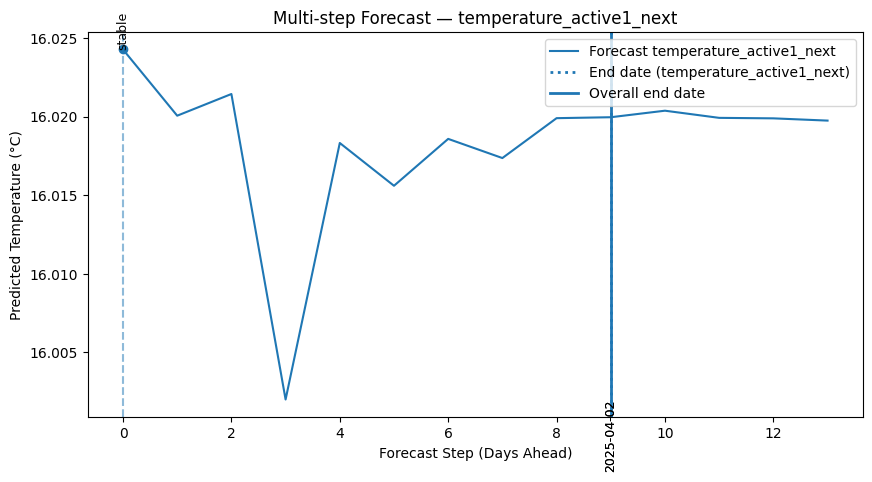

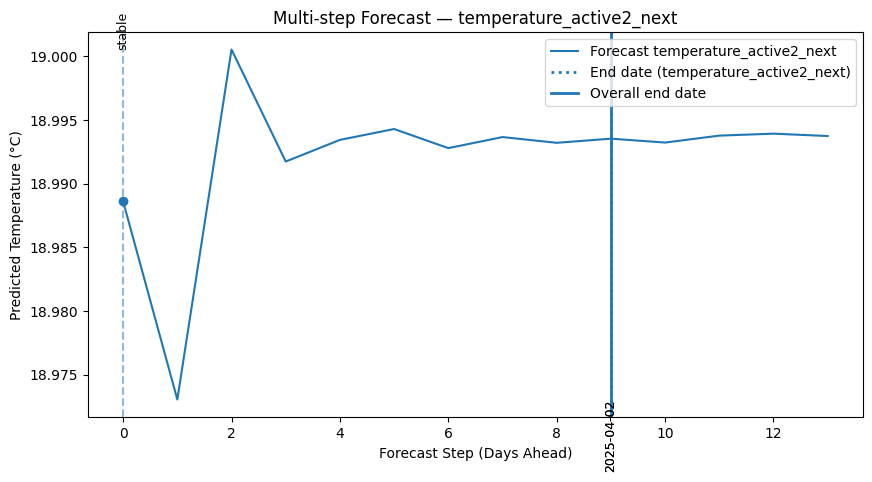

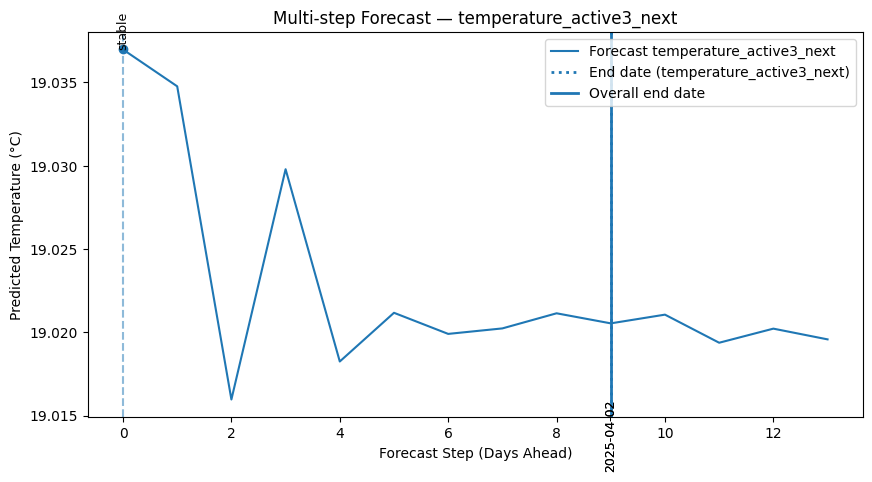

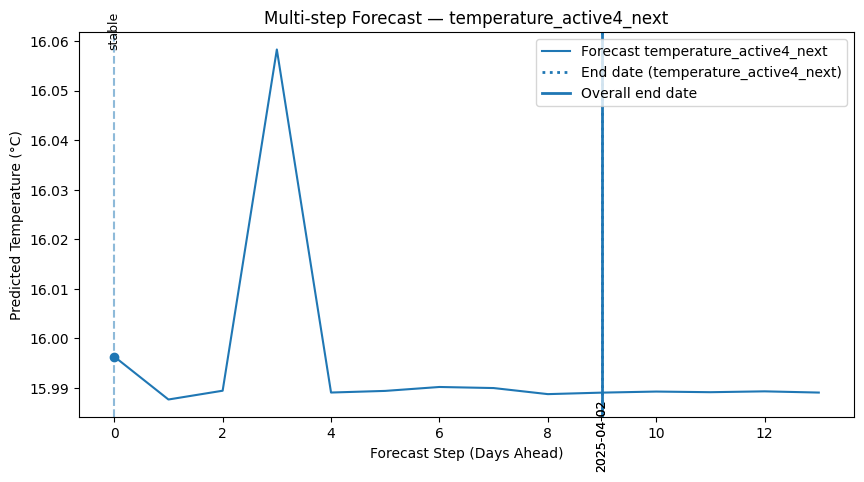

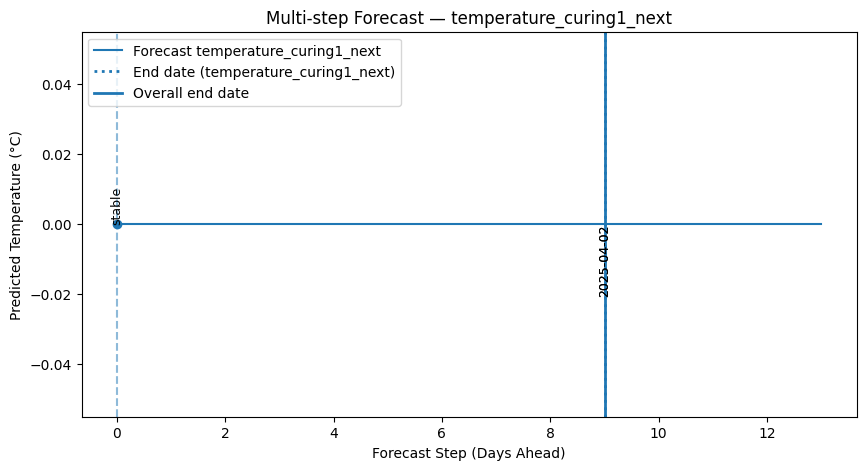

In [19]:
# Plot a few probes; you can loop all if you like
to_plot = ['temperature_active1_next', 'temperature_active2_next', 'temperature_active3_next', 'temperature_active4_next', 'temperature_curing1_next']

for t_next in to_plot:
    plt.figure(figsize=(10,5))
    plt.plot(future_multi.index, future_multi[t_next], label=f'Forecast {t_next}')

    # Phase change verticals (optional)
    if 'phase_change_flag' in future_multi.columns:
        change_ix = future_multi.index[ future_multi['phase_change_flag'] ]
        for i in change_ix:
            plt.axvline(i, linestyle='--', alpha=0.5)
            plt.scatter(i, future_multi.loc[i, t_next], zorder=3)
            if 'pred_phase_next' in future_multi.columns:
                plt.text(i, future_multi[t_next].max(), str(future_multi.loc[i, 'pred_phase_next']),
                         rotation=90, va='bottom', ha='center', fontsize=9)

    # Per-probe end date marker
    row = end_summary[end_summary['temp_next_col'] == t_next]
    if not row.empty and pd.notna(row.iloc[0]['end_date']):
        end_dt = row.iloc[0]['end_date']
        end_idx = future_multi.index[ future_multi['date'] == end_dt ]
        if len(end_idx) > 0:
            end_idx = end_idx[0]
            plt.axvline(end_idx, linestyle=':', linewidth=2, label=f'End date ({t_next})')
            plt.text(end_idx, future_multi[t_next].min(), str(end_dt),
                     rotation=90, va='top', ha='center', fontsize=9)

    # Global/overall end date marker
    if overall_end_date is not None:
        g_idx = future_multi.index[ future_multi['date'] == overall_end_date ]
        if len(g_idx) > 0:
            g_idx = g_idx[0]
            plt.axvline(g_idx, linestyle='-', linewidth=2, label='Overall end date')
            plt.text(g_idx, future_multi[t_next].min(), str(overall_end_date),
                     rotation=90, va='top', ha='center', fontsize=9)

    plt.xlabel("Forecast Step (Days Ahead)")        # X label
    plt.ylabel("Predicted Temperature (°C)")        # Y label
    plt.title(f"Multi-step Forecast — {t_next}")
    plt.legend()
    plt.show()


In [22]:
from pathlib import Path
import joblib, json, time, sys

# Save into repo's models/ folder (if notebook is in notebooks/, go up one level)
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# ---- What you actually trained in this notebook ----
# reg_multi  -> multi-output temperature forecaster
# cls_phase  -> phase classifier
# (no scaler in this notebook)

# Save models
joblib.dump(reg_multi, MODEL_DIR / "forecaster.joblib")
print("Saved forecaster.joblib (reg_multi)")

joblib.dump(cls_phase, MODEL_DIR / "phase.joblib")
print("Saved phase.joblib (cls_phase)")

# Record feature order used by each model (very important for serving!)
FEATURE_ORDER_REG = list(X_train_reg.columns)  # from cell 11
FEATURE_ORDER_CLS = list(X_train_cls.columns)  # from cell 13

# Save feature orders so runtime can build inputs correctly
with open(MODEL_DIR / "feature_order_reg.json", "w") as f:
    json.dump(FEATURE_ORDER_REG, f, indent=2)
with open(MODEL_DIR / "feature_order_cls.json", "w") as f:
    json.dump(FEATURE_ORDER_CLS, f, indent=2)

# Minimal metadata
meta = {
    "saved_at": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    "python": sys.version.split()[0],
    "artifacts": {
        "forecaster": "forecaster.joblib",
        "phase_clf": "phase.joblib",
        "feature_order_reg": "feature_order_reg.json",
        "feature_order_cls": "feature_order_cls.json",
    }
}
with open(MODEL_DIR / "metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Wrote metadata.json and feature order files")


Saved forecaster.joblib (reg_multi)
Saved phase.joblib (cls_phase)
Wrote metadata.json and feature order files
